<a href="https://colab.research.google.com/github/Le-Phu-Family/Learn_PyTorch_101/blob/main/03_pytorch_computer_vision_exercises.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# 03. PyTorch Computer Vision Exercises

The following is a collection of exercises based on computer vision fundamentals in PyTorch.

They're a bunch of fun.

You're going to get to write plenty of code!

## Resources

1. These exercises are based on [notebook 03 of the Learn PyTorch for Deep Learning course](https://www.learnpytorch.io/03_pytorch_computer_vision/).
2. See a live [walkthrough of the solutions (errors and all) on YouTube](https://youtu.be/_PibmqpEyhA).
  * **Note:** Going through these exercises took me just over 3 hours of solid coding, so you should expect around the same.
3. See [other solutions on the course GitHub](https://github.com/mrdbourke/pytorch-deep-learning/tree/main/extras/solutions).

In [2]:
# Check for GPU
!nvidia-smi

Fri Jun  5 14:03:09 2026       
+-----------------------------------------------------------------------------------------+
| NVIDIA-SMI 580.82.07              Driver Version: 580.82.07      CUDA Version: 13.0     |
+-----------------------------------------+------------------------+----------------------+
| GPU  Name                 Persistence-M | Bus-Id          Disp.A | Volatile Uncorr. ECC |
| Fan  Temp   Perf          Pwr:Usage/Cap |           Memory-Usage | GPU-Util  Compute M. |
|                                         |                        |               MIG M. |
|=========================================+========================+======================|
|   0  Tesla T4                       Off |   00000000:00:04.0 Off |                    0 |
| N/A   42C    P8             10W /   70W |       0MiB /  15360MiB |      0%      Default |
|                                         |                        |                  N/A |
+-----------------------------------------+-----

In [3]:
# Import torch
import torch

# Exercises require PyTorch > 1.10.0
print(torch.__version__)

# TODO: Setup device agnostic code
device = "cuda" if torch.cuda.is_available() else "cpu"
device

2.11.0+cu128


'cuda'

## 1. What are 3 areas in industry where computer vision is currently being used?

- Self-driving cars, humor abnormaly detection, Security

## 2. Search "what is overfitting in machine learning" and write down a sentence about what you find.

In [4]:
# Overfitting in ML is a event that your model learn exactly data points like mimick, dont just learn a underlying pattern.
# It will have a high evaluation on training but very bad or low on testing or unseen data.

## 3. Search "ways to prevent overfitting in machine learning", write down 3 of the things you find and a sentence about each.
> **Note:** there are lots of these, so don't worry too much about all of them, just pick 3 and start with those.

In [5]:
# In ML, to prevent overfitting, I use Cross-Validation and Regularization like L1, L2.
# In DL, we can use Dropout or Batch Norm to prevent overfittng as well.
# Additionally, we can use some reduce noise techniques or data augmentation to improve reguralization and diversity of dataset.

## 4. Spend 20-minutes reading and clicking through the [CNN Explainer website](https://poloclub.github.io/cnn-explainer/).

* Upload your own example image using the "upload" button on the website and see what happens in each layer of a CNN as your image passes through it.

## 5. Load the [`torchvision.datasets.MNIST()`](https://pytorch.org/vision/stable/generated/torchvision.datasets.MNIST.html#torchvision.datasets.MNIST) train and test datasets.

In [6]:
import torchvision
from torchvision import datasets, transforms

train_data = torchvision.datasets.MNIST(
    root = ".",
    train = True,
    download = True,
    transform = transforms.ToTensor()
)

test_data = torchvision.datasets.MNIST(
    root = ".",
    train = False,
    download = True,
    transform = transforms.ToTensor()
)

train_data, test_data

100%|██████████| 9.91M/9.91M [00:00<00:00, 20.0MB/s]
100%|██████████| 28.9k/28.9k [00:00<00:00, 484kB/s]
100%|██████████| 1.65M/1.65M [00:00<00:00, 4.45MB/s]
100%|██████████| 4.54k/4.54k [00:00<00:00, 16.2MB/s]


(Dataset MNIST
     Number of datapoints: 60000
     Root location: .
     Split: Train
     StandardTransform
 Transform: ToTensor(),
 Dataset MNIST
     Number of datapoints: 10000
     Root location: .
     Split: Test
     StandardTransform
 Transform: ToTensor())

In [7]:
image, label = train_data[0]
image.shape, label

(torch.Size([1, 28, 28]), 5)

In [8]:
class_names = train_data.classes
class_names

['0 - zero',
 '1 - one',
 '2 - two',
 '3 - three',
 '4 - four',
 '5 - five',
 '6 - six',
 '7 - seven',
 '8 - eight',
 '9 - nine']

## 6. Visualize at least 5 different samples of the MNIST training dataset.

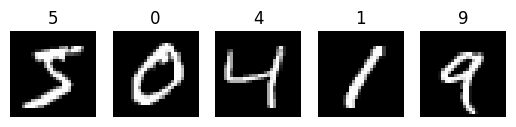

In [9]:
import matplotlib.pyplot as plt

for i in range(5):
  plt.subplot(1, 5, i+1)
  img = train_data[i][0]
  img_squeezed = img.squeeze()
  label = train_data[i][1]
  plt.imshow(img_squeezed, cmap="gray")
  plt.title(label)
  plt.axis(False);

## 7. Turn the MNIST train and test datasets into dataloaders using `torch.utils.data.DataLoader`, set the `batch_size=32`.

In [10]:
from torch.utils.data import DataLoader

train_dataloader = DataLoader(dataset = train_data, batch_size = 32, shuffle = True)
test_dataloader = DataLoader(dataset = test_data, batch_size = 32, shuffle = True)

## 8. Recreate `model_2` used in notebook 03 (the same model from the [CNN Explainer website](https://poloclub.github.io/cnn-explainer/), also known as TinyVGG) capable of fitting on the MNIST dataset.

In [11]:
import torch.nn as nn

class MNIST_model(nn.Module):
  def __init__(self, input_shape: int, hidden_units: int, output_shape: int):
    super().__init__()
    self.block1 = nn.Sequential(
        nn.Conv2d(in_channels = input_shape, out_channels = hidden_units, kernel_size = 3, padding = 1),
        nn.ReLU(),
        nn.Conv2d(in_channels = hidden_units, out_channels = hidden_units, kernel_size = 3, padding = 1),
        nn.ReLU(),
        nn.MaxPool2d(kernel_size = 2, stride = 2)
    )
    self.block2 = nn.Sequential(
        nn.Conv2d(in_channels = hidden_units, out_channels = hidden_units, kernel_size = 3, padding = 1),
        nn.ReLU(),
        nn.Conv2d(in_channels = hidden_units, out_channels = hidden_units, kernel_size = 3, padding = 1),
        nn.ReLU(),
        nn.MaxPool2d(kernel_size = 2, stride = 2)
    )
    self.classifier = nn.Sequential(
        nn.Flatten(),
        nn.Linear(in_features = hidden_units * 7 * 7, out_features = output_shape)
    )


  def forward(self, x):
    x = self.block1(x)
    x = self.block2(x)
    x = self.classifier(x)
    return x

model = MNIST_model(input_shape = 1, hidden_units = 10, output_shape = len(class_names)).to(device)
model

MNIST_model(
  (block1): Sequential(
    (0): Conv2d(1, 10, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (1): ReLU()
    (2): Conv2d(10, 10, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (3): ReLU()
    (4): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  )
  (block2): Sequential(
    (0): Conv2d(10, 10, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (1): ReLU()
    (2): Conv2d(10, 10, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (3): ReLU()
    (4): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  )
  (classifier): Sequential(
    (0): Flatten(start_dim=1, end_dim=-1)
    (1): Linear(in_features=490, out_features=10, bias=True)
  )
)

## 9. Train the model you built in exercise 8. for 5 epochs on CPU and GPU and see how long it takes on each.

In [12]:
%%time
from tqdm.auto import tqdm

loss_fn = nn.CrossEntropyLoss()
optimizer = torch.optim.SGD(params = model.parameters(), lr = 0.1)

epochs = 5
# training
for epoch in tqdm(range(epochs)):
  train_loss = 0
  model.train()
  for batch, (X, y) in enumerate(train_dataloader):
    X, y = X.to(device), y.to(device)
    y_pred = model(X)
    loss = loss_fn(y_pred, y)
    train_loss += loss
    optimizer.zero_grad()
    loss.backward()
    optimizer.step()

  train_loss /= len(train_dataloader)

  # testing
  test_loss = 0
  model.eval()
  with torch.inference_mode():
    for batch, (X_test, y_test) in enumerate(test_dataloader):
      X_test, y_test = X_test.to(device), y_test.to(device)
      test_pred = model(X)
      test_loss = loss_fn(test_pred, y)
      test_loss += test_loss
    test_loss /= len(test_dataloader)
  print(f"Epoch: {epoch} | Loss: {train_loss:.3f} | Test loss: {test_loss:.3f}")




  0%|          | 0/5 [00:00<?, ?it/s]

Epoch: 0 | Loss: 0.309 | Test loss: 0.000
Epoch: 1 | Loss: 0.070 | Test loss: 0.000
Epoch: 2 | Loss: 0.054 | Test loss: 0.001
Epoch: 3 | Loss: 0.047 | Test loss: 0.000
Epoch: 4 | Loss: 0.041 | Test loss: 0.000
CPU times: user 1min, sys: 660 ms, total: 1min
Wall time: 1min 4s


## 10. Make predictions using your trained model and visualize at least 5 of them comparing the prediciton to the target label.

In [13]:
model_logits = model(test_data[0][0].unsqueeze(dim=0).to(device))
model_probs = torch.softmax(model_logits, dim = 1)
model_lables = torch.argmax(model_probs, dim = 1)
model_lables

tensor([7], device='cuda:0')

## 11. Plot a confusion matrix comparing your model's predictions to the truth labels.

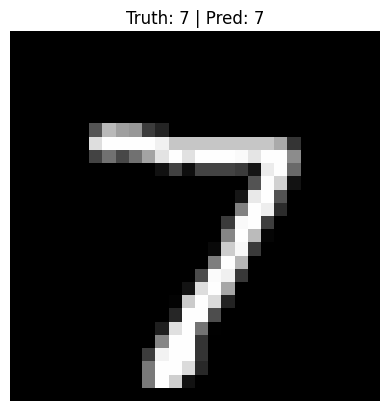

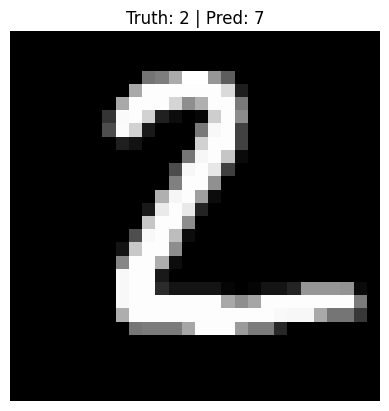

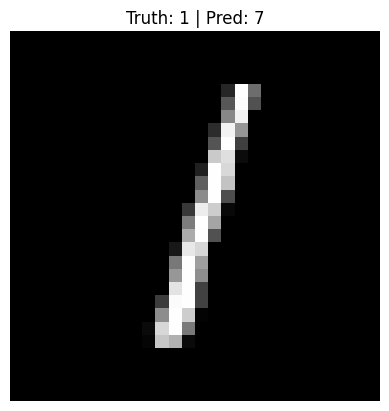

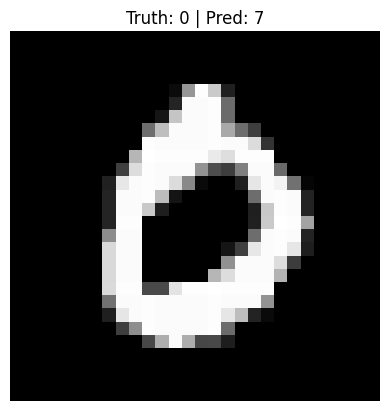

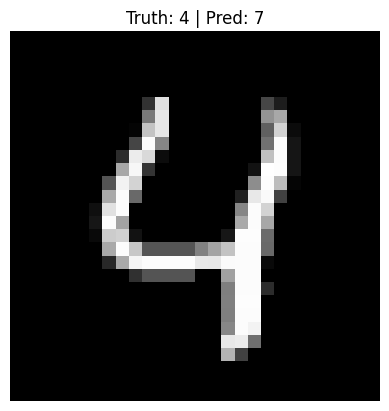

In [14]:
num_to_plot = 5
for i in range(num_to_plot):
  # Get image and labels from the test data
  img = test_data[i][0]
  label = test_data[i][1]

  # Make prediction on image
  model_logits = model(test_data[0][0].unsqueeze(dim=0).to(device))
  model_probs = torch.softmax(model_logits, dim = 1)
  model_labels = torch.argmax(model_probs, dim = 1)

  # Plot the image and prediction
  plt.figure()
  plt.imshow(img.squeeze(), cmap="gray")
  plt.title(f"Truth: {label} | Pred: {model_labels.cpu().item()}")
  plt.axis(False);

## 12. Create a random tensor of shape `[1, 3, 64, 64]` and pass it through a `nn.Conv2d()` layer with various hyperparameter settings (these can be any settings you choose), what do you notice if the `kernel_size` parameter goes up and down?

In [17]:
random_tensor = torch.rand(size = (1,3,64,64))

ConV2d_layer = nn.Conv2d(in_channels = 3, out_channels = 64, kernel_size=3, stride=1, padding=1)
random_tensor_through_conv_layer = ConV2d_layer(random_tensor)
print(f"Random tensor through conv layer shape: {random_tensor_through_conv_layer.shape}")

Random tensor through conv layer shape: torch.Size([1, 64, 64, 64])


## 13. Use a model similar to the trained `model_2` from notebook 03 to make predictions on the test [`torchvision.datasets.FashionMNIST`](https://pytorch.org/vision/main/generated/torchvision.datasets.FashionMNIST.html) dataset.
* Then plot some predictions where the model was wrong alongside what the label of the image should've been.
* After visualing these predictions do you think it's more of a modelling error or a data error?
* As in, could the model do better or are the labels of the data too close to each other (e.g. a "Shirt" label is too close to "T-shirt/top")?

In [38]:
import torch
import torchvision
import torch.nn as nn
from torchvision import datasets, transforms
from torch.utils.data import DataLoader
from tqdm.auto import tqdm
from torchmetrics import Accuracy

import random
import numpy
import matplotlib.pyplot as plt

device = "cuda" if torch.cuda.is_available() else "cpu"
device

'cuda'

In [39]:
fashion_train_data = datasets.FashionMNIST(
    root = ".",
    train = True,
    download = True,
    transform = transforms.ToTensor()
)

fashion_test_data = datasets.FashionMNIST(
    root = ".",
    train = False,
    download = True,
    transform = transforms.ToTensor()
)

In [40]:
fashion_mnist_class_names = fashion_train_data.classes
fashion_mnist_class_names

['T-shirt/top',
 'Trouser',
 'Pullover',
 'Dress',
 'Coat',
 'Sandal',
 'Shirt',
 'Sneaker',
 'Bag',
 'Ankle boot']

In [41]:
train_dataloader = DataLoader(fashion_train_data, batch_size = 32, shuffle = True)
test_dataloader = DataLoader(fashion_test_data, batch_size = 32, shuffle = True)

In [42]:
model1 = MNIST_model(input_shape=1, hidden_units=10, output_shape=len(fashion_mnist_class_names)).to(device)
model1

MNIST_model(
  (block1): Sequential(
    (0): Conv2d(1, 10, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (1): ReLU()
    (2): Conv2d(10, 10, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (3): ReLU()
    (4): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  )
  (block2): Sequential(
    (0): Conv2d(10, 10, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (1): ReLU()
    (2): Conv2d(10, 10, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (3): ReLU()
    (4): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  )
  (classifier): Sequential(
    (0): Flatten(start_dim=1, end_dim=-1)
    (1): Linear(in_features=490, out_features=10, bias=True)
  )
)

In [43]:
loss_fn = nn.CrossEntropyLoss()
optimizer = torch.optim.SGD(model1.parameters(), lr= 0.01)
acc_fn = Accuracy(task = "multiclass", num_classes = len(fashion_mnist_class_names)).to(device)

In [44]:
epochs = 5
for epoch in range(epochs):
  train_loss, test_loss = 0, 0
  train_acc, test_acc = 0, 0

  ### training
  model1.train()
  for batch, (X,y) in enumerate(train_dataloader):
    X_train, y_train = X.to(device), y.to(device)
    y_pred = model1(X_train)
    loss = loss_fn(y_pred, y_train)

    train_acc += acc_fn(y_pred, y_train)
    train_loss += loss

    optimizer.zero_grad()
    loss.backward()
    optimizer.step()

  train_loss /= len(train_dataloader)
  train_acc /= len(train_dataloader)

  ### testing
  model1.eval()
  with torch.inference_mode():
    for batch, (X_test, y_test) in enumerate(test_dataloader):
        X_test, y_test = X_test.to(device), y_test.to(device)
        test_pred = model1(X_test)
        test_loss = loss_fn(test_pred, y_test)
        test_acc += acc_fn(test_pred, y_test)
        test_loss += test_loss

    test_loss /= len(test_dataloader)
    test_acc /= len(test_dataloader)

print(f"Epoch: {epoch} | Train loss: {train_loss:.3f} | Train acc: {train_acc:.2f} | Test loss: {test_loss:.3f} | Test acc: {test_acc:.2f}")

Epoch: 4 | Train loss: 0.376 | Train acc: 0.87 | Test loss: 0.002 | Test acc: 0.86


In [45]:
# make predictions
test_preds = []
model1.eval()
with torch.inference_mode():
  for X_test, y_test in tqdm(test_dataloader):
    y_logits = model1(X_test.to(device))
    y_pred = torch.softmax(y_logits, dim = 1)
    y_labels = torch.argmax(y_pred, dim = 1)
    test_preds.append(y_labels)
test_preds.append(y_pred.cpu())
test_preds[:10], len(test_preds)

  0%|          | 0/313 [00:00<?, ?it/s]

([tensor([4, 5, 7, 9, 7, 8, 2, 9, 9, 3, 7, 4, 0, 5, 4, 1, 0, 6, 2, 8, 3, 6, 8, 9,
          4, 9, 1, 8, 0, 3, 0, 7], device='cuda:0'),
  tensor([9, 3, 4, 9, 1, 8, 6, 7, 2, 0, 7, 2, 6, 7, 3, 5, 9, 8, 4, 4, 6, 3, 8, 5,
          3, 4, 3, 5, 8, 7, 1, 9], device='cuda:0'),
  tensor([9, 4, 2, 9, 9, 3, 1, 9, 9, 0, 3, 8, 5, 5, 2, 4, 3, 1, 2, 8, 0, 0, 7, 3,
          1, 8, 1, 2, 1, 3, 1, 1], device='cuda:0'),
  tensor([1, 0, 7, 0, 7, 3, 9, 6, 6, 6, 0, 7, 0, 1, 5, 6, 1, 9, 4, 5, 0, 5, 9, 4,
          7, 8, 5, 8, 1, 4, 5, 0], device='cuda:0'),
  tensor([4, 0, 1, 4, 9, 8, 9, 1, 5, 8, 5, 2, 5, 4, 0, 8, 3, 0, 6, 7, 8, 4, 9, 9,
          8, 4, 3, 2, 3, 5, 8, 8], device='cuda:0'),
  tensor([6, 8, 0, 4, 6, 8, 3, 0, 4, 3, 6, 3, 2, 3, 1, 7, 4, 6, 9, 7, 8, 4, 6, 0,
          9, 3, 5, 0, 2, 1, 1, 1], device='cuda:0'),
  tensor([3, 4, 9, 9, 2, 0, 6, 9, 0, 7, 4, 2, 3, 4, 4, 7, 7, 9, 6, 6, 5, 5, 5, 7,
          4, 6, 4, 7, 2, 1, 5, 9], device='cuda:0'),
  tensor([9, 3, 4, 7, 1, 8, 1, 8, 0, 0, 2, 3, 2, 4, 0, 

In [48]:
all_test_preds = torch.cat(test_preds[:-1]).to(device) # Concatenate all prediction batches into one tensor
wrong_pred_indexes = torch.where(all_test_preds != fashion_test_data.targets.to(device))[0]
len(wrong_pred_indexes)

8951

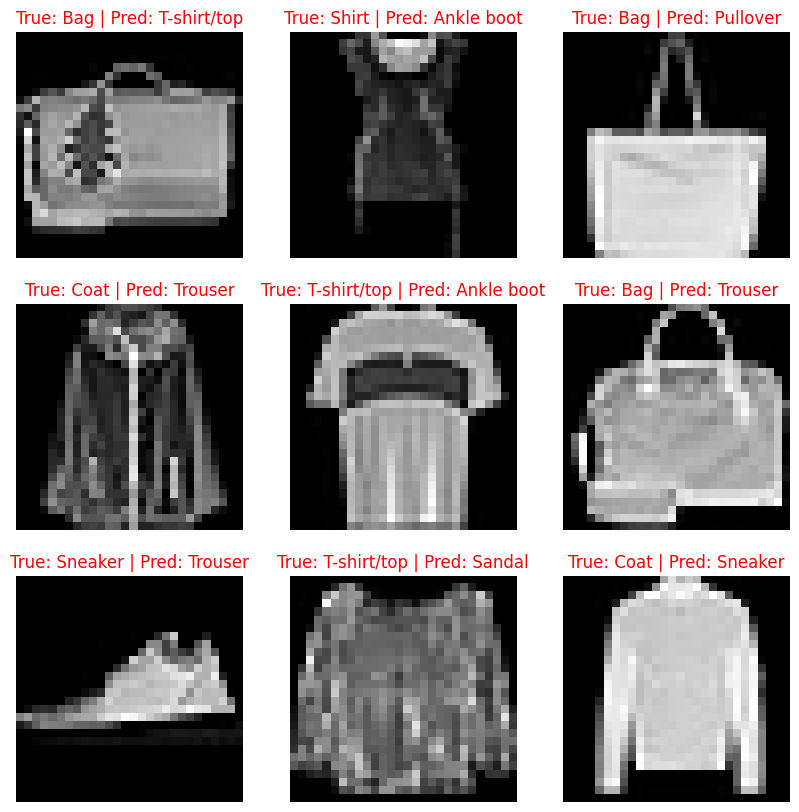

In [49]:
# Select random wrong predictions and plot them
num_to_sample = min(len(wrong_pred_indexes), 9) # Sample up to 9 wrong predictions, or fewer if less are available
random_selection = random.sample(list(wrong_pred_indexes.cpu().numpy()), k=num_to_sample)

plt.figure(figsize=(10, 10))
for i, idx in enumerate(random_selection):
  # Get true and pred labels
  true_label = fashion_mnist_class_names[fashion_test_data[idx][1]]
  # We need to get the prediction from all_test_preds using the index
  pred_label = fashion_mnist_class_names[all_test_preds[idx]]

  # Plot the wrong prediction with its original label
  plt.subplot(int(np.ceil(num_to_sample/3)), 3, i+1)
  plt.imshow(fashion_test_data[idx][0].squeeze(), cmap="gray")
  plt.title(f"True: {true_label} | Pred: {pred_label}", c="r")
  plt.axis(False);